# A100 — OP-12 θ firewall screening (SU(3) Wilson gauge)

**Run:** Runtime → Change runtime type → **A100 GPU**, then **Runtime → Run all**.
No editing required. To scale up, edit the `CONFIG` block in the last cell.

Generates SU(3) Wilson configurations on the GPU and computes the **OP-12 Birman–Schwinger
firewall** observable along a β ladder:

$$\theta(U)=v_0\,\lambda_{\max}\big(\Pi_D\,P\,M^{-1}\,P\,\Pi_D\big),\qquad M=m_0^2 I+\tfrac{\beta}{6}\,d_1^{*}d_1,$$

with $P$ the coexact (Hodge) projector and defects the plaquette-seeded links $s_p=1-\mathrm{Re\,tr}\,U_p/3>\delta$.
θ < 1 is the firewall holding. **In the sparse regime θ is the float64-exact dense eigenvalue**
(an independent residual-stopped power iteration cross-checks the dense assembly via a hard gate);
the **rational certificate stays the CPU M2 job**.

**Outputs** (`/content/op12_gpu_out`): per-(L,β) `results_*.json` / `meta_*.json`, `summary.json`, and a
θ-vs-β plot (shown inline). FP64 throughout; optimized for A100 (device-scalar CG, single-sync sweep,
on-device rotation pool).

In [1]:
# --- setup: detect GPU, install CuPy if needed (Colab CUDA 12.x) ---
import subprocess, sys
try:
    import cupy as cp
    print("CuPy already present:", cp.__version__)
except Exception:
    print("Installing cupy-cuda12x (Colab CUDA 12.x) ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "cupy-cuda12x"], check=False)
    import cupy as cp
    print("CuPy installed:", cp.__version__)
try:
    n = cp.cuda.runtime.getDeviceCount()
    nm = cp.cuda.runtime.getDeviceProperties(0)["name"]
    nm = nm.decode() if isinstance(nm, bytes) else nm
    print(f"GPU devices: {n}  ->  {nm}")
    if "A100" not in nm:
        print("NOTE: not an A100; runs anyway, but pick an A100 runtime for the intended throughput.")
except Exception as e:
    print("No CUDA GPU visible:", e)
    print("Code falls back to CPU (slow). Use Runtime > Change runtime type > A100 GPU.")


CuPy already present: 14.0.1
GPU devices: 1  ->  NVIDIA A100-SXM4-40GB


SELF-TEST (validates full pipeline + EVERY gate incl. power==dense xcheck)
backend       : CuPy/GPU [NVIDIA A100-SXM4-40GB]
lattice       : L=4  sites=256  links=1024
[L4_b6.0] gates  P^2=P=1.0e-13  [M,P]=0=5.9e-15  OK
[L4_b6.0] sweeps/s=     2.0 <plaq>=0.6654 tau=nan  | d=0.9[dense_exact]: max=0.1766 p50=0.1556

DONE. In the sparse regime theta is the float64-EXACT dense eigenvalue (power-iteration cross-checked). The RATIONAL certificate stays the CPU M2 job.

SELF-TEST PASS: end-to-end, all gates held, power==dense theta, finite.

>>> self-test passed on this hardware; starting the configured run

backend       : CuPy/GPU [NVIDIA A100-SXM4-40GB]
lattice       : L=6  sites=1296  links=5184
[L6_b6.0] gates  P^2=P=9.7e-14  [M,P]=0=5.5e-15  OK
[L6_b6.0] sweeps/s=     0.6 <plaq>=0.5992 tau=2.45  | d=0.9[dense_exact]: max=0.3085 p50=0.2795  | d=1.1[dense_exact]: max=0.1603 p50=0.1383
[L6_b6.8] gates  P^2=P=1.0e-13  [M,P]=0=5.2e-15  OK
[L6_b6.8] sweeps/s=     1.0 <plaq>=0.6610 tau=1.07  | 

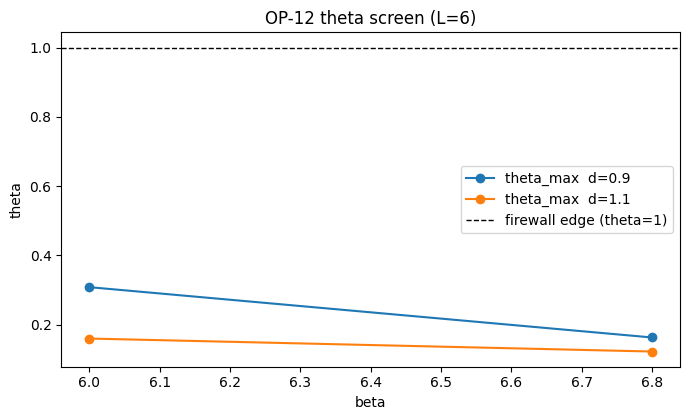

In [2]:
# ==== OP-12 theta screening v2 (optimized for A100) -- single program cell ====
#!/usr/bin/env python3
# op12_a100_screen_v2_opt.py -- v2 science (dense-exact theta cross-check) with
# two A100 hot-path optimizations that DO NOT change results:
#   (1) device-scalar CG: alpha/beta/residual stay on the GPU; host sync only
#       every `check_every` iterations (was: a host sync every iteration).
#   (2) single-sync Metropolis sweep: acceptance accumulated on device, brought
#       to host once per sweep (was: 16 host syncs per sweep).
# Everything else is identical to op12_a100_screen_v2.py.
import os, sys, json, time, math, argparse
import numpy as np
import scipy.sparse as ssp

USE_GPU = False
try:
    import cupy as cp
    import cupyx.scipy.sparse as xsp_gpu
    if cp.cuda.runtime.getDeviceCount() > 0:
        USE_GPU = True
except Exception:
    cp = None

if USE_GPU:
    xp = cp; xsp = xsp_gpu
    _d = cp.cuda.runtime.getDeviceProperties(cp.cuda.runtime.getDevice())
    BACKEND = f"CuPy/GPU [{_d['name'].decode() if isinstance(_d['name'],bytes) else _d['name']}]"
else:
    xp = np; xsp = ssp; BACKEND = "NumPy/CPU"

def to_host(a): return cp.asnumpy(a) if (USE_GPU and isinstance(a, cp.ndarray)) else np.asarray(a)
def asdev(a):   return cp.asarray(a) if USE_GPU else np.asarray(a)
def dag(M):     return xp.conj(xp.swapaxes(M, -1, -2))

# -------- device-scalar CG (opt 1) --------
def cg_solve(matvec, b, tol=1e-10, maxiter=30000, check_every=10):
    x = xp.zeros_like(b); r = b - matvec(x); p = r.copy()
    rs = xp.dot(r, r)                              # device scalar
    bnorm2 = float(xp.dot(b, b)) + 1e-300
    tol2 = (tol * tol) * bnorm2
    if float(rs) <= tol2:
        return x, 0
    for it in range(maxiter):
        Ap = matvec(p)
        denom = xp.dot(p, Ap)
        alpha = rs / denom                         # device scalar, no host transfer
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = xp.dot(r, r)
        if (it % check_every) == 0 and float(rs_new) <= tol2:
            return x, 0
        p = r + (rs_new / rs) * p
        rs = rs_new
    return x, (0 if float(rs) <= tol2 else 1)

# -------- lattice --------
def build_lattice(L):
    D = 4; Ns = L**D; Nl = D * Ns
    ORIS = [(mu, nu) for mu in range(D) for nu in range(mu + 1, D)]
    coords = np.array([[s % L, (s//L) % L, (s//L**2) % L, (s//L**3) % L]
                       for s in range(Ns)], dtype=np.int64)
    def sidx(x): return ((x[3]*L + x[2])*L + x[1])*L + x[0]
    nbr = np.zeros((Ns, D), dtype=np.int64); pbr = np.zeros((Ns, D), dtype=np.int64)
    for s in range(Ns):
        for mu in range(D):
            xp_ = coords[s].copy(); xp_[mu] = (xp_[mu]+1) % L
            xm_ = coords[s].copy(); xm_[mu] = (xm_[mu]-1) % L
            nbr[s, mu] = sidx(xp_); pbr[s, mu] = sidx(xm_)
    rows, cols, vals = [], [], []
    for s in range(Ns):
        for mu in range(D):
            l = 4*s+mu; rows += [l, l]; cols += [nbr[s, mu], s]; vals += [1.0, -1.0]
    d0 = ssp.csr_matrix((vals, (rows, cols)), shape=(Nl, Ns))
    rows, cols, vals = [], [], []
    Np_ = 6*Ns; plinks = np.zeros((Np_, 4), dtype=np.int64)
    for s in range(Ns):
        for oi, (mu, nu) in enumerate(ORIS):
            p = 6*s+oi
            ls = [4*s+mu, 4*nbr[s, mu]+nu, 4*nbr[s, nu]+mu, 4*s+nu]
            plinks[p] = ls; rows += [p]*4; cols += ls; vals += [1.0, 1.0, -1.0, -1.0]
    d1 = ssp.csr_matrix((vals, (rows, cols)), shape=(Np_, Nl))
    assert abs(d1 @ d0).max() == 0.0, 'GATE FAIL: d1 d0 != 0'
    L0 = (d0.T @ d0).tocsr(); L1up = (d1.T @ d1).tocsr()
    return dict(D=D, Ns=Ns, Nl=Nl, ORIS=ORIS, plinks=plinks,
                nbr=asdev(nbr), pbr=asdev(pbr),
                d0=xsp.csr_matrix(d0), d0T=xsp.csr_matrix(d0.T.tocsr()),
                L0=xsp.csr_matrix(L0), L1up=xsp.csr_matrix(L1up))

# -------- SU(3) --------
_lam = np.zeros((8, 3, 3), dtype=np.complex128)
_lam[0][0,1]=_lam[0][1,0]=1; _lam[1][0,1]=-1j; _lam[1][1,0]=1j
_lam[2][0,0]=1; _lam[2][1,1]=-1
_lam[3][0,2]=_lam[3][2,0]=1; _lam[4][0,2]=-1j; _lam[4][2,0]=1j
_lam[5][1,2]=_lam[5][2,1]=1; _lam[6][1,2]=-1j; _lam[6][2,1]=1j
_lam[7][0,0]=_lam[7][1,1]=1/math.sqrt(3); _lam[7][2,2]=-2/math.sqrt(3)
_LAM_DEV = asdev(_lam)

def rotation_pool(eps, n):
    # device-resident: H = sum a_i lambda_i (Hermitian, traceless), expm(i eps H)
    # via batched eigh, so det R = exp(i eps tr H) = 1 exactly.
    a = asdev(np.random.standard_normal((n, 8)).astype(np.float64)) if not USE_GPU \
        else xp.random.standard_normal((n, 8), dtype=xp.float64)
    H = xp.einsum('na,aij->nij', a.astype(xp.complex128), _LAM_DEV)
    w, V = xp.linalg.eigh(H)
    phase = xp.exp(1j * eps * w)
    R = (V * phase[:, None, :]) @ dag(V)
    return xp.concatenate([R, dag(R)], axis=0)

def reunitarize(U):
    c0 = U[..., :, 0]; c1 = U[..., :, 1]
    c0 = c0 / xp.linalg.norm(c0, axis=-1, keepdims=True)
    c1 = c1 - xp.sum(xp.conj(c0)*c1, axis=-1, keepdims=True)*c0
    c1 = c1 / xp.linalg.norm(c1, axis=-1, keepdims=True)
    c2 = xp.conj(xp.cross(c0, c1))
    return xp.stack([c0, c1, c2], axis=-1)

def staples(lat, U, mu):
    D, nbr, pbr = lat['D'], lat['nbr'], lat['pbr']
    A = xp.zeros((lat['Ns'], 3, 3), dtype=xp.complex128); smu = nbr[:, mu]
    for nu in range(D):
        if nu == mu: continue
        snu = nbr[:, nu]
        A = A + U[smu, nu] @ dag(U[snu, mu]) @ dag(U[:, nu])
        sm = pbr[:, nu]; smmu = nbr[sm, mu]
        A = A + dag(U[smmu, nu]) @ dag(U[sm, mu]) @ U[sm, nu]
    return A

# -------- single-sync sweep (opt 2) --------
def metropolis_sweep(lat, U, beta, pool, pmask, npar, nhit=1):
    D = lat['Ns'], lat['D']; Ns = lat['Ns']; npool = pool.shape[0]
    acc_dev = xp.zeros((), dtype=xp.int64); att = 0
    for mu in range(lat['D']):
        for color in (0, 1):
            A = staples(lat, U, mu); pm = pmask[color]
            for _hit in range(nhit):
                idx = xp.random.randint(0, npool, size=Ns); R = pool[idx]
                Uo = U[:, mu]; Up = R @ Uo; dlt = Up - Uo
                dS = -(beta/3.0) * xp.real(xp.einsum('sij,sji->s', dlt, A))
                u = xp.random.random(Ns)
                accept = (dS <= 0) | (u < xp.exp(-xp.clip(dS, 0.0, 700.0)))
                sel = accept & pm
                U[:, mu] = xp.where(sel[:, None, None], Up, Uo)
                acc_dev = acc_dev + xp.count_nonzero(sel); att += npar[color]
    return float(to_host(acc_dev)) / max(att, 1)        # one host sync per sweep

def plaquette_field(lat, U):
    ORIS, nbr = lat['ORIS'], lat['nbr']
    out = xp.zeros(6*lat['Ns'], dtype=xp.float64)
    for oi, (mu, nu) in enumerate(ORIS):
        smu = nbr[:, mu]; snu = nbr[:, nu]
        Upl = U[:, mu] @ U[smu, nu] @ dag(U[snu, mu]) @ dag(U[:, nu])
        out[oi::6] = 1.0 - xp.real(xp.einsum('sii->s', Upl)) / 3.0
    return out

# -------- theta --------
def make_M_matvec(lat, beta, m2):
    L1up = lat['L1up']
    def mv(v): return m2*v + (beta/6.0)*(L1up @ v)
    return mv

def proj_P(lat, f, tol=1e-11):
    b = lat['d0T'] @ f; b = b - b.mean()
    z, info = cg_solve(lambda v: lat['L0'] @ v + 1e-12*v, b, tol=tol)
    assert info == 0, 'GATE FAIL: CG(L0) did not converge'
    z = z - z.mean(); return f - lat['d0'] @ z

def gate_PM(lat, Mmv, rng):
    v = asdev(rng.standard_normal(lat['Nl']))
    Pv = proj_P(lat, v); PPv = proj_P(lat, Pv)
    e1 = float(xp.linalg.norm(PPv-Pv))/(1+float(xp.linalg.norm(Pv)))
    assert e1 < 1e-6, f'GATE FAIL: P^2 != P ({e1:.2e})'
    MPv = Mmv(Pv); PMPv = proj_P(lat, MPv)
    e2 = float(xp.linalg.norm(PMPv-MPv))/(1+float(xp.linalg.norm(MPv)))
    assert e2 < 1e-5, f'GATE FAIL: [M,P] != 0 ({e2:.2e})'
    return e1, e2

def theta_power(lat, dlinks, Mmv, v0, rng, iters=1000, tol_res=1e-9):
    # Residual-stopped power iteration. The Rayleigh-quotient-change stop fires
    # PREMATURELY on the near-degenerate top spectra typical of the defect
    # operator (lam1/lam0 ~ 0.98); the residual ||Bx-lam x|| measures eigenvector
    # convergence directly and is robust to that clustering.
    mask = np.zeros(lat['Nl']); mask[dlinks] = 1.0; mask = asdev(mask)
    def Bmat(x):
        y = proj_P(lat, mask*x)
        z, info = cg_solve(Mmv, y, tol=1e-10)
        assert info == 0, 'GATE FAIL: CG(M) did not converge'
        return mask*proj_P(lat, z)
    x = asdev(rng.standard_normal(lat['Nl']))*mask; x = x/xp.linalg.norm(x)
    lam_ = 0.0
    for it in range(iters):
        y = Bmat(x); lam_ = float(xp.dot(x, y)); ny = float(xp.linalg.norm(y))
        if ny == 0.0: return 0.0
        resid = float(xp.linalg.norm(y - lam_*x))
        x = y/ny
        if it > 5 and resid <= tol_res*max(1.0, abs(lam_)): break
    assert math.isfinite(lam_), 'GATE FAIL: theta not finite'
    return v0*lam_

def theta_dense_exact(lat, dlinks, Mmv, v0):
    dl = [int(i) for i in dlinks]; nD = len(dl)
    dl_dev = asdev(np.array(dl, dtype=np.int64))
    Bcols = np.zeros((nD, nD), dtype=np.float64)
    for b, i in enumerate(dl):
        e = xp.zeros(lat['Nl']); e[i] = 1.0
        y = proj_P(lat, e)
        z, info = cg_solve(Mmv, y, tol=1e-12)
        assert info == 0, 'GATE FAIL: dense CG(M) did not converge'
        Bcols[:, b] = to_host(proj_P(lat, z)[dl_dev])
    Bsym = 0.5*(Bcols + Bcols.T)
    asym = float(np.max(np.abs(Bcols-Bsym)))/(1+float(np.max(np.abs(Bsym))))
    assert asym < 1e-6, f'GATE FAIL: defect operator not self-adjoint ({asym:.2e})'
    return v0*float(np.linalg.eigvalsh(Bsym)[-1])

def theta_of(lat, spl, delta, Mmv, v0, rng, dense_cap=1500, xcheck=True):
    bad = spl > delta; nbad = int(to_host(xp.count_nonzero(bad)))
    if nbad == 0:
        return dict(theta=0.0, rhoP=0.0, rhoL=0.0, nD=0, method='none', xcheck_res=0.0)
    bad_h = to_host(bad).astype(bool)
    dlinks = np.unique(lat['plinks'][bad_h].ravel())
    nD = int(len(dlinks))
    res = dict(rhoP=nbad/spl.shape[0], rhoL=nD/lat['Nl'], nD=nD, xcheck_res=0.0)
    if nD <= dense_cap:
        th = theta_dense_exact(lat, dlinks, Mmv, v0); res['method'] = 'dense_exact'
        if xcheck:
            thp = theta_power(lat, dlinks, Mmv, v0, rng)
            r = abs(th-thp)/max(1.0, abs(th))
            res['xcheck_res'] = r
            # dense is the authoritative (machine-precision) value; this gate guards
            # the dense ASSEMBLY against the independent power operator. A real
            # assembly/sign/transpose bug shows O(1); 1e-3 tolerates the residual
            # slack power iteration retains on near-degenerate (lam1/lam0~0.98) spectra.
            assert r < 1e-3, f'GATE FAIL: power vs dense theta disagree ({r:.2e}) -- assembly/operator bug'
        res['theta'] = th
    else:
        res['theta'] = theta_power(lat, dlinks, Mmv, v0, rng); res['method'] = 'power_only'
    return res

def integrated_autocorr_time(x):
    x = np.asarray(x, dtype=float); n = len(x)
    if n < 4: return float('nan')
    x = x - x.mean(); var = np.dot(x, x)/n
    if var <= 0: return 0.5
    tau = 0.5
    for lag in range(1, min(n//2, 1000)):
        rho = np.dot(x[:-lag], x[lag:])/((n-lag)*var)
        if rho <= 0: break
        tau += rho
    return float(tau)

# -------- driver --------
def run(args):
    print(f"backend       : {BACKEND}")
    betas = [float(b) for b in args.betas.split(',')]
    deltas = [float(d) for d in args.deltas.split(',')]
    os.makedirs(args.out, exist_ok=True)
    lat = build_lattice(args.L)
    print(f"lattice       : L={args.L}  sites={lat['Ns']}  links={lat['Nl']}")
    if USE_GPU: xp.random.seed(args.seed)
    else: np.random.seed(args.seed)
    par = (np.array([[s % args.L, (s//args.L) % args.L, (s//args.L**2) % args.L,
                      (s//args.L**3) % args.L] for s in range(lat['Ns'])]).sum(1) % 2)
    pmask = [asdev(par == 0), asdev(par == 1)]
    npar = [int((par == 0).sum()), int((par == 1).sum())]
    gate_rng = np.random.default_rng(args.seed + 99)

    summary = {}
    for beta in betas:
        tag = f"L{args.L}_b{beta}"
        rpath = os.path.join(args.out, f'results_{tag}.json')
        if os.path.exists(rpath) and not args.force:
            print(f"[{tag}] done -> skip (resume; --force to redo)")
            try: summary[tag] = json.load(open(os.path.join(args.out, f'meta_{tag}.json')))
            except Exception: pass
            continue
        Mmv = make_M_matvec(lat, beta, args.m2)
        if not args.no_theta:
            e1, e2 = gate_PM(lat, Mmv, gate_rng)
            print(f"[{tag}] gates  P^2=P={e1:.1e}  [M,P]=0={e2:.1e}  OK")

        U = xp.zeros((lat['Ns'], lat['D'], 3, 3), dtype=xp.complex128)
        U[:] = xp.eye(3, dtype=xp.complex128); eps = 0.22
        t0 = time.time(); sweeps = 0
        for it in range(args.therm):
            pool = rotation_pool(eps, args.npool)
            a = metropolis_sweep(lat, U, beta, pool, pmask, npar, nhit=args.nhit)
            if a < 0.35: eps *= 0.94
            elif a > 0.65: eps *= 1.06
            if (it+1) % args.reunit == 0: U = reunitarize(U)
            sweeps += 1
        if USE_GPU: cp.cuda.runtime.deviceSynchronize()
        t_therm = time.time() - t0
        UU = U @ dag(U); uni = float(xp.max(xp.abs(UU - xp.eye(3, dtype=xp.complex128))))
        assert uni < 1e-8, f'GATE FAIL: link unitarity drift {uni:.2e}'

        res = {'cfg': []}; t1 = time.time()
        for c in range(args.ncfg):
            for _ in range(args.sep):
                pool = rotation_pool(eps, args.npool)
                a = metropolis_sweep(lat, U, beta, pool, pmask, npar, nhit=args.nhit)
                if a < 0.35: eps *= 0.94
                elif a > 0.65: eps *= 1.06
                sweeps += 1
            U = reunitarize(U)
            spl = plaquette_field(lat, U)
            mp = float(1.0 - spl.mean())
            assert -0.05 < mp < 1.05, f'GATE FAIL: plaquette out of range {mp}'
            entry = {'cfg': c, 'plaq': mp}
            if not args.no_theta:
                for dl in deltas:
                    out = theta_of(lat, spl, dl, Mmv, args.v0, gate_rng,
                                   dense_cap=args.dense_cap, xcheck=(c < args.xcheck_ncfg))
                    entry[f'theta_d{dl}'] = out['theta']; entry[f'method_d{dl}'] = out['method']
                    entry[f'rhoL_d{dl}'] = out['rhoL']; entry[f'rhoP_d{dl}'] = out['rhoP']
                    entry[f'nD_d{dl}'] = out['nD']
            res['cfg'].append(entry)
        if USE_GPU: cp.cuda.runtime.deviceSynchronize()
        t_meas = time.time() - t1
        sps = sweeps / max(t_therm + t_meas, 1e-9)
        plaqs = [e['plaq'] for e in res['cfg']]; tau = integrated_autocorr_time(plaqs)
        json.dump(res, open(rpath, 'w'), indent=1)
        meta = dict(L=args.L, beta=beta, therm=args.therm, ncfg=args.ncfg, sep=args.sep,
                    m2=args.m2, v0=args.v0, deltas=deltas, backend=BACKEND, sweeps=sweeps,
                    sweeps_per_sec=sps, t_therm=t_therm, t_meas=t_meas, eps_final=eps,
                    mean_plaq=(float(np.mean(plaqs)) if plaqs else None), tau_int_plaq=tau)
        for dl in deltas:
            if not args.no_theta and plaqs:
                ths = [e[f'theta_d{dl}'] for e in res['cfg']]
                meta[f'theta_max_d{dl}'] = float(max(ths)); meta[f'theta_p50_d{dl}'] = float(np.median(ths))
                meta[f'theta_tau_int_d{dl}'] = integrated_autocorr_time(ths)
        json.dump(meta, open(os.path.join(args.out, f'meta_{tag}.json'), 'w'), indent=1)
        line = f"[{tag}] sweeps/s={sps:8.1f} <plaq>={np.mean(plaqs):.4f} tau={tau:.2f}" if plaqs \
               else f"[{tag}] sweeps/s={sps:8.1f} (therm only)"
        if not args.no_theta and plaqs:
            for dl in deltas:
                ths = [e[f'theta_d{dl}'] for e in res['cfg']]; m = res['cfg'][0].get(f'method_d{dl}', '?')
                line += f"  | d={dl}[{m}]: max={max(ths):.4f} p50={np.median(ths):.4f}"
        print(line)
        if tau > args.sep:
            print(f"   WARN: tau_int({tau:.1f})>sep({args.sep}) -> configs autocorrelated; increase --sep.")
        summary[tag] = meta
    json.dump(summary, open(os.path.join(args.out, 'summary.json'), 'w'), indent=1)
    print("\nDONE. In the sparse regime theta is the float64-EXACT dense eigenvalue "
          "(power-iteration cross-checked). The RATIONAL certificate stays the CPU M2 job.")
    return summary

def selftest():
    print("="*72)
    print("SELF-TEST (validates full pipeline + EVERY gate incl. power==dense xcheck)")
    print("="*72)
    ns = argparse.Namespace(L=4, betas='6.0', deltas='0.9', therm=30, ncfg=3, sep=2,
                            m2=0.5, v0=1.0, npool=64, reunit=10, seed=20260614, nhit=1,
                            dense_cap=1500, xcheck_ncfg=3, force=True, out='op12_v2opt_selftest',
                            no_theta=False)
    s = run(ns)
    print("\nSELF-TEST PASS: end-to-end, all gates held, power==dense theta, finite.")
    return s


# =============================== CONFIG (edit me) =============================
from types import SimpleNamespace
OUT = "/content/op12_gpu_out" if os.path.isdir("/content") else "./op12_gpu_out"
# PILOT default: completes quickly on an A100. Uncomment PRODUCTION to scale up.
CONFIG = SimpleNamespace(
    L           = 6,             # isotropic L^4 lattice; raise to 8,10,12 to scale
    betas       = "6.0,6.8",     # beta ladder (comma-separated)
    deltas      = "0.9,1.1",     # defect thresholds; 0.7 percolates (expensive)
    therm       = 120,           # thermalization sweeps (cold start)
    ncfg        = 16,            # measured configs per beta
    sep         = 4,             # sweeps between measurements (raise if tau_int > sep)
    nhit        = 1,             # Metropolis hits per link per color
    m2          = 0.5,           # m0^2 in M = m0^2 I + (beta/6) d1* d1
    v0          = 1.0,           # defect weight
    npool       = 96,            # rotation-pool size
    reunit      = 25,            # reunitarize links every N sweeps
    seed        = 20260614,
    dense_cap   = 1500,          # exact dense eigensolve when |D| <= this, else power iter
    xcheck_ncfg = 3,             # power-vs-dense cross-check on this many configs/beta
    out         = OUT, force = False, no_theta = False,
)
# ---- PRODUCTION (uncomment; minutes-to-tens-of-minutes on an A100) ----
# CONFIG.L, CONFIG.betas, CONFIG.deltas = 8, "5.6,6.0,6.4,6.8,7.2", "0.7,0.9,1.1"
# CONFIG.therm, CONFIG.ncfg, CONFIG.sep = 200, 40, 5

RUN_SELFTEST_FIRST = True        # validate every hard gate on THIS hardware first
# =============================================================================

def plot_theta_vs_beta(args, summary):
    import matplotlib.pyplot as plt
    tags = [t for t in summary if t.startswith(f"L{args.L}_b")]
    if not tags:
        print("(no completed tags to plot)"); return
    bs = sorted({summary[t]["beta"] for t in tags})
    dls = [float(d) for d in args.deltas.split(",")]
    plt.figure(figsize=(7, 4.3))
    for dl in dls:
        ys = [summary.get(f"L{args.L}_b{b}", {}).get(f"theta_max_d{dl}", float("nan")) for b in bs]
        plt.plot(bs, ys, marker="o", label=f"theta_max  d={dl}")
    plt.axhline(1.0, ls="--", lw=1, color="k", label="firewall edge (theta=1)")
    plt.xlabel("beta"); plt.ylabel("theta"); plt.title(f"OP-12 theta screen (L={args.L})")
    plt.legend(); plt.tight_layout()
    p = os.path.join(args.out, f"theta_vs_beta_L{args.L}.png"); plt.savefig(p, dpi=160)
    print("saved plot:", p)
    try: plt.show()
    except Exception: pass

if RUN_SELFTEST_FIRST:
    selftest()
    print("\n>>> self-test passed on this hardware; starting the configured run\n")

summary = run(CONFIG)
plot_theta_vs_beta(CONFIG, summary)
